In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### loading the csv files


In [2]:
customers = pd.read_csv('/Users/goofy/Desktop/customer-360-ecommerce-intelligence/data/raw/customers.csv')

In [3]:
products = pd.read_csv('../data/raw/products.csv')

In [4]:
orders = pd.read_csv('../data/raw/orders.csv')
order_items = pd.read_csv('../data/raw/order_items.csv')

### checking for each table
-shape
-info
-header
-isnull().sum()
-duplicates

In [5]:
print(customers.shape)
customers.info()

print(customers.head())
print(customers.isnull().sum())
print(customers.duplicated().sum())


(5012, 7)
<class 'pandas.DataFrame'>
RangeIndex: 5012 entries, 0 to 5011
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          5012 non-null   str    
 1   signup_date          5012 non-null   str    
 2   gender               4861 non-null   str    
 3   age                  4836 non-null   float64
 4   city                 5012 non-null   str    
 5   state                4911 non-null   str    
 6   acquisition_channel  5012 non-null   str    
dtypes: float64(1), str(6)
memory usage: 274.2 KB
  customer_id signup_date  gender   age      city           state  \
0      C04872  2025-08-26  Female  30.0  Guwahati           Assam   
1      C01026  2025-04-29  Female  32.0   Udaipur       Rajasthan   
2      C03193  2026-01-21    Male  56.0   Kolkata     West Bengal   
3      C02895  2024-03-15    Male   NaN    Mumbai     Maharashtra   
4      C04393  2025-06-03  Female  39.0    Indore 

In [6]:
print(orders.shape)
orders.info()
print(orders.head())
print(orders.isnull().sum())
print(orders.duplicated().sum())


(27543, 7)
<class 'pandas.DataFrame'>
RangeIndex: 27543 entries, 0 to 27542
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         27543 non-null  str    
 1   customer_id      27543 non-null  str    
 2   order_date       27543 non-null  str    
 3   payment_method   27130 non-null  str    
 4   order_status     27543 non-null  str    
 5   discount_amount  27543 non-null  float64
 6   shipping_fee     27543 non-null  float64
dtypes: float64(2), str(5)
memory usage: 1.5 MB
  order_id customer_id  order_date    payment_method order_status  \
0  O026838      C04030  2026-08-09        Debit Card    Completed   
1  O022611      C02873  2025-03-23               UPI    Completed   
2  O003844      C02851  2025-12-23               UPI    Completed   
3  O002908      C01615  2025-04-23  Cash on Delivery    Completed   
4  O012141      C00559  2026-07-29               UPI    Completed   

   discount_amo

In [7]:
print(order_items.shape)
order_items.info()
print(order_items.head())
print(order_items.isnull().sum())
print(order_items.duplicated().sum())

(59220, 5)
<class 'pandas.DataFrame'>
RangeIndex: 59220 entries, 0 to 59219
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  59220 non-null  str    
 1   order_id       59220 non-null  str    
 2   product_id     59220 non-null  str    
 3   quantity       59220 non-null  int64  
 4   unit_price     59220 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 2.3 MB
  order_item_id order_id product_id  quantity  unit_price
0     OI0005573  O002594      P0082         1      2319.0
1     OI0048314  O022613      P0027         1      3309.0
2     OI0028345  O013280      P0114         1      2449.0
3     OI0019820  O009291      P0110         1      2369.0
4     OI0007300  O003430      P0032         3      2129.0
order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
dtype: int64
25


### customers_clean

In [8]:
customers_clean = customers.drop_duplicates()

In [9]:
print(products.shape)
products.info()
print(products.head())
print(products.isnull().sum())
print(products.duplicated().sum())

(130, 6)
<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    130 non-null    str    
 1   product_name  130 non-null    str    
 2   category      130 non-null    str    
 3   subcategory   130 non-null    str    
 4   unit_price    130 non-null    float64
 5   cost_price    130 non-null    float64
dtypes: float64(2), str(4)
memory usage: 6.2 KB
  product_id          product_name                category  \
0      P0001  Cookware Set Classic          Home & Kitchen   
1      P0002            Kurti Mini                 Apparel   
2      P0003        Hand Wash Lite  Beauty & Personal Care   
3      P0004   Cotton T-Shirt Plus                 Apparel   
4      P0005    Laptop Sleeve Lite             Electronics   

          subcategory  unit_price  cost_price  
0            Cookware      1479.0     1017.08  
1    Women's Clothing      1919.0    

In [10]:
# Age: numeric, some missing -> fill with median (robust to outliers/invalid ages)
customers_clean['age'] = customers_clean['age'].fillna(customers_clean['age'].median())

# Gender: categorical, some missing -> fill with 'Unknown' rather than guessing
customers_clean['gender'] = customers_clean['gender'].fillna('Unknown')

# State: categorical, some missing -> fill with 'Unknown'
customers_clean['state'] = customers_clean['state'].fillna('Unknown')

In [11]:
customers_clean.loc[(customers_clean['age'] < 15) | (customers_clean['age'] > 90), 'age'] = np.nan
customers_clean['age'] = customers_clean['age'].fillna(customers_clean['age'].median())

In [12]:
customers_clean['city'] = customers_clean['city'].str.strip().str.title()

In [13]:
print(customers.shape)

(5012, 7)


In [14]:
print(customers.isnull().sum())

customer_id              0
signup_date              0
gender                 151
age                    176
city                     0
state                  101
acquisition_channel      0
dtype: int64


In [15]:
customers_clean['age'].describe()

count    5000.000000
mean       31.644800
std         8.469532
min        18.000000
25%        25.000000
50%        31.000000
75%        37.000000
max        65.000000
Name: age, dtype: float64

In [16]:
print(customers_clean.shape)
print(customers_clean.isnull().sum())
print(customers_clean['age'].describe())

(5000, 7)
customer_id            0
signup_date            0
gender                 0
age                    0
city                   0
state                  0
acquisition_channel    0
dtype: int64
count    5000.000000
mean       31.644800
std         8.469532
min        18.000000
25%        25.000000
50%        31.000000
75%        37.000000
max        65.000000
Name: age, dtype: float64


In [17]:
customers_clean['city'].unique()

<StringArray>
[          'Guwahati',            'Udaipur',            'Kolkata',
             'Mumbai',             'Indore',      'Visakhapatnam',
               'Pune',             'Mysuru',         'Vijayawada',
              'Surat',              'Patna',         'Chandigarh',
         'Coimbatore',             'Nagpur',          'Ahmedabad',
             'Jaipur',          'Hyderabad',          'Faridabad',
             'Ranchi',             'Bhopal',              'Noida',
              'Delhi',        'Bhubaneswar', 'Thiruvananthapuram',
            'Chennai',           'Gurugram',            'Lucknow',
              'Kochi',             'Kanpur',          'Bengaluru']
Length: 30, dtype: str

## Customer Cleaning Summary
- Removed 12 exact duplicate rows (5012 → 5000)
- Filled missing age (176), gender (151), state (101) — see comments in code for rationale
- Corrected 5 invalid age values (negative, 0, 100+) before imputing
- Standardized city capitalization (e.g. GURUGRAM → Gurugram)
  

### products_clean

In [18]:
products_clean = products.drop_duplicates()

In [19]:
products_clean['category'].unique()

<StringArray>
[        'Home & Kitchen',                'Apparel', 'Beauty & Personal Care',
            'Electronics',       'Sports & Fitness',       'Home and Kitchen',
                'APPAREL',     'Sports and Fitness',            'electronics',
 'beauty & personal care']
Length: 10, dtype: str

In [20]:
category_map = {
    'Home and Kitchen': 'Home & Kitchen',
    'APPAREL': 'Apparel',
    'Sports and Fitness': 'Sports & Fitness',
    'electronics': 'Electronics',
    'beauty & personal care': 'Beauty & Personal Care',
}

products_clean['category'] = products_clean['category'].replace(category_map)

In [21]:
products_clean['category'].unique()

<StringArray>
[        'Home & Kitchen',                'Apparel', 'Beauty & Personal Care',
            'Electronics',       'Sports & Fitness']
Length: 5, dtype: str

In [22]:
products_clean['cost_data_reliable'] = products_clean['cost_price'] <= products_clean['unit_price']

In [23]:
products_clean[products_clean['cost_data_reliable'] == False]

,product_id,product_name,category,subcategory,unit_price,cost_price,cost_data_reliable
43,P0044,Tripod Stand Plus,Electronics,Cameras,3739.0,4666.31,False
71,P0072,Laptop Sleeve Plus,Electronics,Laptop Accessories,2649.0,3107.28,False
72,P0073,Screen Guard Pro,Electronics,Mobile Accessories,1649.0,1777.65,False


## Product Cleaning Summary
- No duplicate rows found
- Standardized 5 category naming inconsistencies via explicit mapping dictionary
  (e.g. 'electronics' → 'Electronics', 'Home and Kitchen' → 'Home & Kitchen')
- Flagged 3 products where cost_price > unit_price as cost_data_reliable = False
  rather than dropping or guessing a corrected cost — these will be excluded from
  profit calculations only, not from revenue or other analysis

### orders_clean

In [24]:
orders_clean = orders.drop_duplicates()

In [85]:
orders_clean['payment_method']=orders_clean['payment_method'].fillna('Unknown')

In [86]:
orders_clean['discount_amount'] = orders_clean['discount_amount'].abs()

In [87]:
print(orders_clean.shape)
orders_clean['discount_amount'].describe()

(27523, 7)


count    27523.000000
mean       312.590927
std        537.863294
min          0.000000
25%          0.000000
50%          0.000000
75%        457.470000
max       5444.210000
Name: discount_amount, dtype: float64

In [88]:
orders_clean.isnull().sum()

order_id           0
customer_id        0
order_date         0
payment_method     0
order_status       0
discount_amount    0
shipping_fee       0
dtype: int64

## Orders Cleaning Summary
- Removed 20 exact duplicate rows (27543 → 27523)
- Filled missing payment_method (413) with 'Unknown' — no reliable basis to guess
  a specific method for a given order
- Corrected 15 negative discount_amount values using abs() — treated as a sign
  error rather than invalid data, since discounts cannot conceptually be negative
  but the magnitude is likely real

### order_items_clean

In [89]:
order_items_clean=order_items.drop_duplicates()

In [90]:
order_items_clean['quantity']=order_items_clean['quantity'].abs()

In [91]:
# Build a lookup of correct prices from the (already cleaned) products table
price_lookup = products_clean.set_index('product_id')['unit_price']

# Where unit_price is 0, replace it with the real product price
zero_price_mask = order_items_clean['unit_price'] == 0
order_items_clean.loc[zero_price_mask, 'unit_price'] = order_items_clean.loc[zero_price_mask, 'product_id'].map(price_lookup)

In [92]:
order_items_clean['quantity_outlier'] = order_items_clean['quantity'] > 10

In [93]:
order_items_clean['unit_price'].describe()

count    59195.000000
mean      1917.952107
std       1084.199872
min        169.000000
25%       1109.000000
50%       1829.000000
75%       2519.000000
max       4869.000000
Name: unit_price, dtype: float64

In [94]:
order_items_clean['quantity'].describe()

count    59195.000000
mean         1.358730
std          0.813353
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         60.000000
Name: quantity, dtype: float64

In [95]:
order_items_clean['quantity_outlier'].sum()

np.int64(10)

In [96]:
print(order_items_clean.shape)

(59195, 6)


## Order Items Cleaning Summary
- Removed 25 exact duplicate rows (59220 → 59195)
- Corrected 8 negative quantity values using abs() — same sign-error logic as
  discount_amount
- Fixed 12 unit_price = 0 rows by looking up the real product price from
  products_clean — a 0 price would have silently understated revenue for
  real transactions, so this wasn't optional
- Flagged 10 unusually large quantities (25-60) as quantity_outlier = True
  rather than altering them — these are unusual but not impossible, and
  likely represent genuine bulk orders

### importing the clean csv to project folder

In [97]:
customers_clean.to_csv('../data/cleaned/customers_clean.csv', index=False)
products_clean.to_csv('../data/cleaned/products_clean.csv', index=False)
orders_clean.to_csv('../data/cleaned/orders_clean.csv', index=False)
order_items_clean.to_csv('../data/cleaned/order_items_clean.csv', index=False)

### RFM Analysis
- Calculating Recency, Frequency, and Monetary value per customer using only
- Completed orders, based on the fixed reference date 2026-08-31.

In [98]:
# RECENCY- how long since the customer's last purchase (lower = better)

REFERENCE_DATE = pd.Timestamp('2026-08-31')

# only completed orders count toward RFM
completed_orders = orders_clean[orders_clean['order_status'] == 'Completed'].copy()
completed_orders['order_date'] = pd.to_datetime(completed_orders['order_date'])

# Recency: days since each customer's most recent completed order
recency_df = completed_orders.groupby('customer_id')['order_date'].max().reset_index()
recency_df['recency'] = (REFERENCE_DATE - recency_df['order_date']).dt.days
recency_df = recency_df[['customer_id', 'recency']]

In [99]:
print(recency_df)

     customer_id  recency
0         C00002       12
1         C00003      163
2         C00004      142
3         C00005      118
4         C00006       32
...          ...      ...
4829      C04996       26
4830      C04997       44
4831      C04998      193
4832      C04999      173
4833      C05000       84

[4834 rows x 2 columns]


In [100]:
# Frequency — how many orders they've placed (higher = better)

frequency_df = (
    completed_orders
    .groupby('customer_id')['order_id']
    .nunique()
    .reset_index(name='frequency')
)

frequency_df.head()

,customer_id,frequency
0,C00002,1
1,C00003,3
2,C00004,4
3,C00005,1
4,C00006,2


In [101]:
# Monetary — how much revenue they've generated (higher = better)
monetary_df = completed_orders[['order_id', 'customer_id']].merge(
    order_items_clean[['order_id', 'quantity', 'unit_price']],
    on='order_id',
    how='inner'
)

monetary_df['revenue'] = monetary_df['quantity'] * monetary_df['unit_price']

monetary_df = (
    monetary_df
    .groupby('customer_id')['revenue']
    .sum()
    .reset_index(name='monetary')
)

In [102]:
print(monetary_df)

     customer_id  monetary
0         C00002    9127.0
1         C00003   13693.0
2         C00004   11366.0
3         C00005    7338.0
4         C00006    6755.0
...          ...       ...
4829      C04996   63618.0
4830      C04997   12493.0
4831      C04998   13163.0
4832      C04999    5754.0
4833      C05000    2449.0

[4834 rows x 2 columns]


In [103]:
#combine all three
rfm = (
    recency_df
    .merge(frequency_df, on='customer_id')
    .merge(monetary_df, on='customer_id')
)

In [104]:

rfm.describe()

,recency,frequency,monetary
count,4834.000000,4834.000000,4834.000000
mean,126.970004,4.856640,27190.672942
std,127.073191,3.913022,29937.410037
min,0.000000,1.000000,169.000000
25%,35.000000,2.000000,7898.500000
50%,76.000000,4.000000,17311.500000
75%,183.000000,7.000000,35479.250000
max,606.000000,18.000000,269996.000000


In [105]:
rfm.head()

,customer_id,recency,frequency,monetary
0,C00002,12,1,9127.0
1,C00003,163,3,13693.0
2,C00004,142,4,11366.0
3,C00005,118,1,7338.0
4,C00006,32,2,6755.0


## RFM Scoring
- The raw Recency, Frequency, and Monetary values are converted into scores from 1 to 5 using quintile-based scoring.

In [106]:
# RFM scoring — 1 to 5

rfm['R_score'] = pd.qcut(
    rfm['recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    5,
    labels=[1, 2, 3, 4, 5]
)

In [107]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(int)
    + rfm['F_score'].astype(int)
    + rfm['M_score'].astype(int)
)

In [108]:
rfm.head(10)

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,C00002,12,1,9127.0,5,1,2,8
1,C00003,163,3,13693.0,2,2,3,7
2,C00004,142,4,11366.0,2,3,2,7
3,C00005,118,1,7338.0,2,1,2,5
4,C00006,32,2,6755.0,4,2,2,8
5,C00007,18,5,15099.0,5,3,3,11
6,C00008,193,1,588.0,2,1,1,4
7,C00009,4,1,5238.0,5,1,1,7
8,C00010,80,12,51359.0,3,5,5,13
9,C00011,216,6,23711.0,1,4,4,9


In [109]:
rfm[['R_score', 'F_score', 'M_score', 'RFM_score']].describe()

,RFM_score
count,4834.000000
mean,9.005999
std,3.062857
min,3.000000
25%,7.000000
50%,9.000000
75%,11.000000
max,15.000000


In [110]:
rfm['RFM_score'].value_counts().sort_index()

RFM_score
3     165
4     233
5     290
6     430
7     529
8     510
9     488
10    503
11    530
12    473
13    314
14    250
15    119
Name: count, dtype: int64

### Customer Segmentation
- RFM scores are converted into five actionable customer segments using transparent business rules.

- Champions — high Recency, Frequency, and Monetary scores
- Loyal Customers — relatively recent and repeat purchasers
- Potential Loyalists — recent customers with low purchase frequency
- At Risk — previously active customers who have not purchased recently
- Lost — customers with weak recent engagement and purchase behavior


In [111]:
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'
    
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'Potential Loyalists'
    
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

### Senity check 

In [112]:
rfm['segment'].value_counts()

segment
Lost                   1163
Loyal Customers        1146
At Risk                1137
Potential Loyalists     771
Champions               617
Name: count, dtype: int64

In [113]:
rfm.groupby('segment').agg(
    customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).sort_values('customers', ascending=False)

,customers,avg_recency,avg_frequency,avg_monetary
segment,,,,
Lost,1163,198.031814,1.579536,8750.021496
Loyal Customers,1146,53.662304,5.717277,29398.409250
At Risk,1137,249.010554,7.003518,39443.046614
Potential Loyalists,771,27.661479,1.623865,9269.243839
Champions,617,28.384117,9.518639,57665.364668


### RFM Segmentation Sanity Check

The resulting segments show expected behavioral patterns:

- Champions have the lowest average recency, highest purchase frequency, and highest monetary value.
- Potential Loyalists are recent customers with relatively low purchase frequency.
- At Risk customers have high historical frequency and monetary value but have not purchased recently.
- Loyal Customers show relatively recent and repeated purchasing behavior.
- Lost customers have high recency and low purchase frequency.

The segment sizes are not expected to be equal because the segmentation rules are based on combinations of RFM scores rather than fixed customer percentages.

### Customer-Level EDA & Business Analysis
-What does our customer base actually look like, and where is the business opportunity?

In [114]:
# How many customers are in each RFM segment?
segment_summary = (
    rfm['segment']
    .value_counts()
    .reset_index()
)

segment_summary.columns = ['segment', 'customer_count']

segment_summary

,segment,customer_count
0,Lost,1163
1,Loyal Customers,1146
2,At Risk,1137
3,Potential Loyalists,771
4,Champions,617


In [115]:
# Which segments generate the most revenue?
segment_revenue = (
    rfm.groupby('segment')
    .agg(
        customers=('customer_id', 'count'),
        total_revenue=('monetary', 'sum'),
        avg_revenue=('monetary', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
)

segment_revenue

,customers,total_revenue,avg_revenue
segment,,,
At Risk,1137,44846744.0,39443.046614
Champions,617,35579530.0,57665.364668
Loyal Customers,1146,33690577.0,29398.409250
Lost,1163,10176275.0,8750.021496
Potential Loyalists,771,7146587.0,9269.243839


In [116]:
# What percentage of total revenue comes from each segment?
segment_revenue['revenue_percentage'] = (
    segment_revenue['total_revenue']
    / rfm['monetary'].sum()
    * 100
).round(2)

segment_revenue

,customers,total_revenue,avg_revenue,revenue_percentage
segment,,,,
At Risk,1137,44846744.0,39443.046614,34.12
Champions,617,35579530.0,57665.364668,27.07
Loyal Customers,1146,33690577.0,29398.409250,25.63
Lost,1163,10176275.0,8750.021496,7.74
Potential Loyalists,771,7146587.0,9269.243839,5.44


In [117]:
# How much revenue is potentially at risk?
at_risk = rfm[rfm['segment'] == 'At Risk']

at_risk_summary = {
    'at_risk_customers': at_risk['customer_id'].nunique(),
    'at_risk_revenue': round(at_risk['monetary'].sum(), 2)
}

at_risk_summary

{'at_risk_customers': 1137, 'at_risk_revenue': np.float64(44846744.0)}

In [118]:
# Which customers are the highest-value customers?

top_customers = (
    rfm
    .sort_values('monetary', ascending=False)
    [['customer_id', 'monetary', 'frequency', 'recency', 'segment']]
    .head(10)
)

top_customers

,customer_id,monetary,frequency,recency,segment
2515,C02593,269996.0,17,8,Champions
3455,C03565,258565.0,18,256,At Risk
770,C00794,239852.0,17,236,At Risk
3525,C03636,233974.0,16,4,Champions
1331,C01374,219959.0,8,202,At Risk
1529,C01579,217363.0,17,4,Champions
2785,C02873,217267.0,16,12,Champions
4824,C04991,216367.0,16,171,At Risk
666,C00685,212703.0,14,58,Loyal Customers
4269,C04415,211863.0,17,12,Champions


## Customer-Level EDA & Business Analysis

This section examines customer behavior and value using the RFM dataset created in Step 3.

The analysis focuses on five business questions:

1. How is the customer base distributed across RFM segments?
2. Which customer segments generate the most revenue?
3. What percentage of total revenue does each segment contribute?
4. How much historical revenue is associated with customers currently classified as At Risk?
5. Which customers generate the highest revenue?

The objective is to move from customer-level metrics to actionable business insights that can later be incorporated into the Power BI dashboard.

## Product & Order-Level Business Analysis

This section analyzes product and order performance to understand which categories and products drive revenue and how customers' completed purchases contribute to overall business performance.

The analysis focuses on three questions:

1. Which product categories generate the most revenue?
2. Which products generate the most revenue?
3. What does the completed-order performance look like?

Only completed orders are included in revenue calculations to maintain consistency with the SQL and RFM analysis.

In [119]:
# Which product categories generate the most revenue?
category_revenue = (
    completed_orders[['order_id']]
    .merge(order_items_clean, on='order_id')
    .merge(products_clean[['product_id', 'category']], on='product_id')
)

category_revenue['revenue'] = (
    category_revenue['quantity'] *
    category_revenue['unit_price']
)

category_revenue = (
    category_revenue
    .groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
    .round(2)
)

category_revenue

category
Home & Kitchen            36565330.0
Electronics               35219954.0
Apparel                   29507996.0
Sports & Fitness          25916127.0
Beauty & Personal Care     4230306.0
Name: revenue, dtype: float64

In [120]:
## Which products generate the most revenue?
product_revenue = (
    completed_orders[['order_id']]
    .merge(order_items_clean, on='order_id')
    .merge(
        products_clean[['product_id', 'product_name', 'category']],
        on='product_id'
    )
)

product_revenue['revenue'] = (
    product_revenue['quantity'] *
    product_revenue['unit_price']
)

top_products = (
    product_revenue
    .groupby(['product_id', 'product_name', 'category'])['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
)

top_products

product_id  product_name              category        
P0099       Wireless Earbuds Classic  Electronics         7199984.0
P0115       Bicycle Bottle Holder     Sports & Fitness    6946070.0
P0097       Photo Frame Set Plus      Home & Kitchen      6693711.0
P0041       Badminton Racket          Sports & Fitness    5547510.0
P0127       Power Bank Lite           Electronics         5472430.0
P0078       Kids Frock Plus           Apparel             4610940.0
P0082       Comforter Plus            Home & Kitchen      4311021.0
P0019       Pillow Set Plus           Home & Kitchen      3609610.0
P0048       Maxi Dress                Apparel             3600128.0
P0061       Resistance Bands Lite     Sports & Fitness    2980611.0
Name: revenue, dtype: float64

In [121]:
## What does completed-order performance look like?
completed_order_summary = (
    completed_orders
    .merge(
        order_items_clean[['order_id', 'quantity', 'unit_price']],
        on='order_id'
    )
)

completed_order_summary['revenue'] = (
    completed_order_summary['quantity'] *
    completed_order_summary['unit_price']
)

completed_order_summary = {
    'completed_orders': completed_orders['order_id'].nunique(),
    'total_revenue': round(completed_order_summary['revenue'].sum(), 2),
    'average_order_value': round(
        completed_order_summary.groupby('order_id')['revenue']
        .sum()
        .mean(), 2
    )
}

completed_order_summary

{'completed_orders': 23477,
 'total_revenue': np.float64(131439713.0),
 'average_order_value': np.float64(5598.66)}

## Final Dataset Preparation & Export

This final step prepares the cleaned and analyzed datasets for use in Power BI.

The exported datasets include:

- Cleaned customer data
- Cleaned product data
- Cleaned order data
- Cleaned order-item data
- Customer-level RFM analysis and segmentation

These datasets provide the foundation for the Power BI dashboard and final business analysis.

In [122]:
customer_360 = customers_clean.merge(
    rfm,
    on='customer_id',
    how='left'
)

customer_360.head()

,customer_id,signup_date,gender,age,city,state,acquisition_channel,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,C04872,2025-08-26,Female,30.0,Guwahati,Assam,Paid Ads,360.0,10.0,34273.0,1,5,4,10.0,At Risk
1,C01026,2025-04-29,Female,32.0,Udaipur,Rajasthan,Organic Search,12.0,8.0,18915.0,5,5,3,13.0,Loyal Customers
2,C03193,2026-01-21,Male,56.0,Kolkata,West Bengal,Referral,169.0,9.0,55639.0,2,5,5,12.0,At Risk
3,C02895,2024-03-15,Male,31.0,Mumbai,Maharashtra,Paid Ads,21.0,3.0,22618.0,5,3,3,11.0,Loyal Customers
4,C04393,2025-06-03,Female,39.0,Indore,Madhya Pradesh,Organic Search,60.0,1.0,4568.0,3,1,1,5.0,Lost


In [123]:
customer_360.isnull().sum()

customer_id              0
signup_date              0
gender                   0
age                      0
city                     0
state                    0
acquisition_channel      0
recency                166
frequency              166
monetary               166
R_score                166
F_score                166
M_score                166
RFM_score              166
segment                166
dtype: int64

In [124]:
print("Customer 360 shape:", customer_360.shape)

Customer 360 shape: (5000, 15)


In [125]:
customer_360.head()

,customer_id,signup_date,gender,age,city,state,acquisition_channel,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,C04872,2025-08-26,Female,30.0,Guwahati,Assam,Paid Ads,360.0,10.0,34273.0,1,5,4,10.0,At Risk
1,C01026,2025-04-29,Female,32.0,Udaipur,Rajasthan,Organic Search,12.0,8.0,18915.0,5,5,3,13.0,Loyal Customers
2,C03193,2026-01-21,Male,56.0,Kolkata,West Bengal,Referral,169.0,9.0,55639.0,2,5,5,12.0,At Risk
3,C02895,2024-03-15,Male,31.0,Mumbai,Maharashtra,Paid Ads,21.0,3.0,22618.0,5,3,3,11.0,Loyal Customers
4,C04393,2025-06-03,Female,39.0,Indore,Madhya Pradesh,Organic Search,60.0,1.0,4568.0,3,1,1,5.0,Lost


In [126]:
customer_360.to_csv(
    '../data/cleaned/customer_360_final.csv',
    index=False
)

In [127]:
rfm.to_csv(
    '../data/cleaned/rfm_customer_segments.csv',
    index=False
)

In [128]:
customer_360.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   customer_id          5000 non-null   str     
 1   signup_date          5000 non-null   str     
 2   gender               5000 non-null   str     
 3   age                  5000 non-null   float64 
 4   city                 5000 non-null   str     
 5   state                5000 non-null   str     
 6   acquisition_channel  5000 non-null   str     
 7   recency              4834 non-null   float64 
 8   frequency            4834 non-null   float64 
 9   monetary             4834 non-null   float64 
 10  R_score              4834 non-null   category
 11  F_score              4834 non-null   category
 12  M_score              4834 non-null   category
 13  RFM_score            4834 non-null   float64 
 14  segment              4834 non-null   str     
dtypes: category(3), float64(5), str(

In [129]:
customer_360['segment'].value_counts(dropna=False)

segment
Lost                   1163
Loyal Customers        1146
At Risk                1137
Potential Loyalists     771
Champions               617
NaN                     166
Name: count, dtype: int64

In [130]:
customer_360['segment'] = customer_360['segment'].fillna(
    'No Completed Purchase'
)

In [131]:
customer_360['segment'].value_counts()

segment
Lost                     1163
Loyal Customers          1146
At Risk                  1137
Potential Loyalists       771
Champions                 617
No Completed Purchase     166
Name: count, dtype: int64

In [132]:
customer_360.to_csv(
    '../data/cleaned/customer_360_final.csv',
    index=False
)

rfm.to_csv(
    '../data/cleaned/rfm_customer_segments.csv',
    index=False
)

# Exploratory Data Analysis (EDA) Visualizations

This section uses Matplotlib to visualize key findings from the customer, RFM, product, and order analysis.

Each visualization is designed to answer a specific business question rather than simply display data.


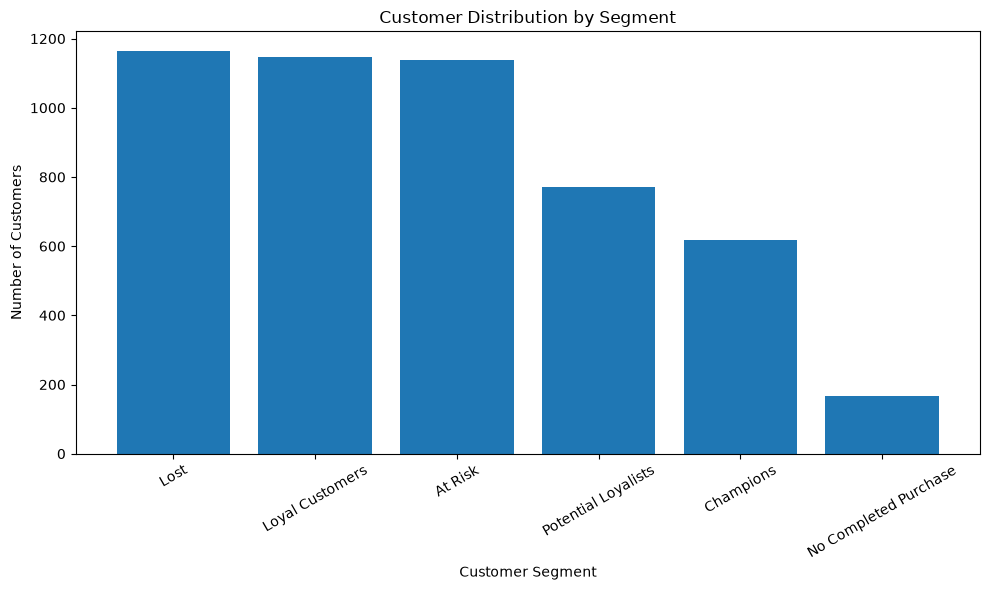

In [133]:
## Chart 1 — How are customers distributed across segments?
import matplotlib.pyplot as plt
segment_counts = customer_360['segment'].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(segment_counts.index, segment_counts.values)

plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

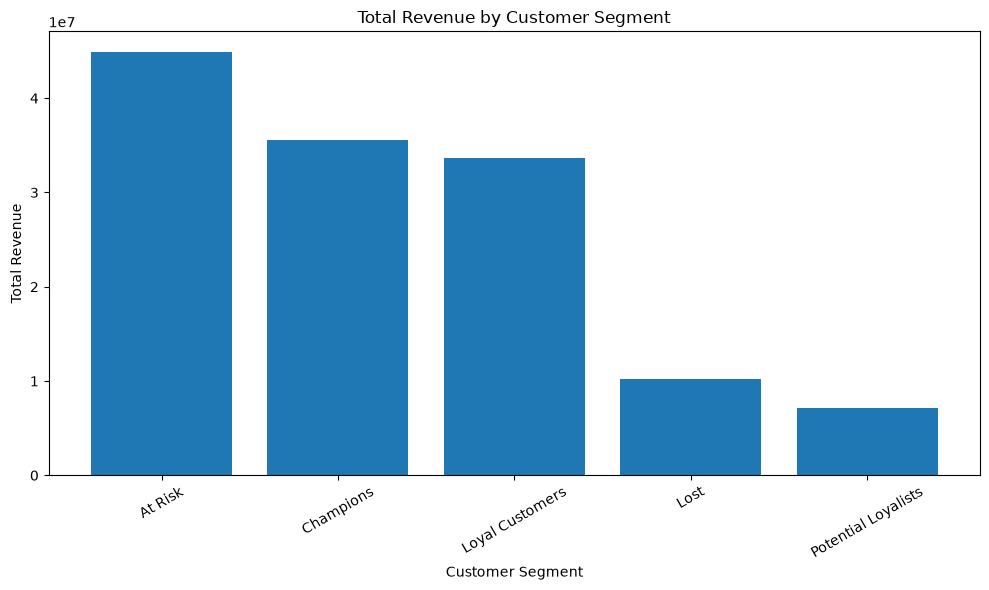

In [134]:
## Chart 2 — Which customer segments generate the most revenue?
segment_revenue_chart = (
    rfm.groupby('segment')['monetary']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_revenue_chart.index,
    segment_revenue_chart.values
)

plt.title('Total Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

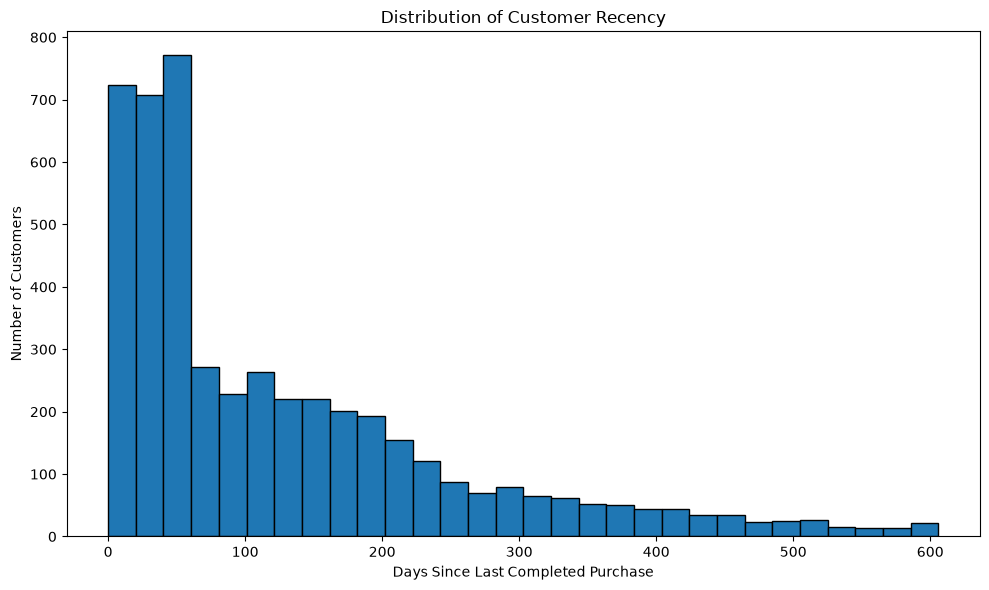

In [135]:
## Chart 3 — What is the distribution of customer recency?
plt.figure(figsize=(10, 6))

plt.hist(
    rfm['recency'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Customer Recency')
plt.xlabel('Days Since Last Completed Purchase')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

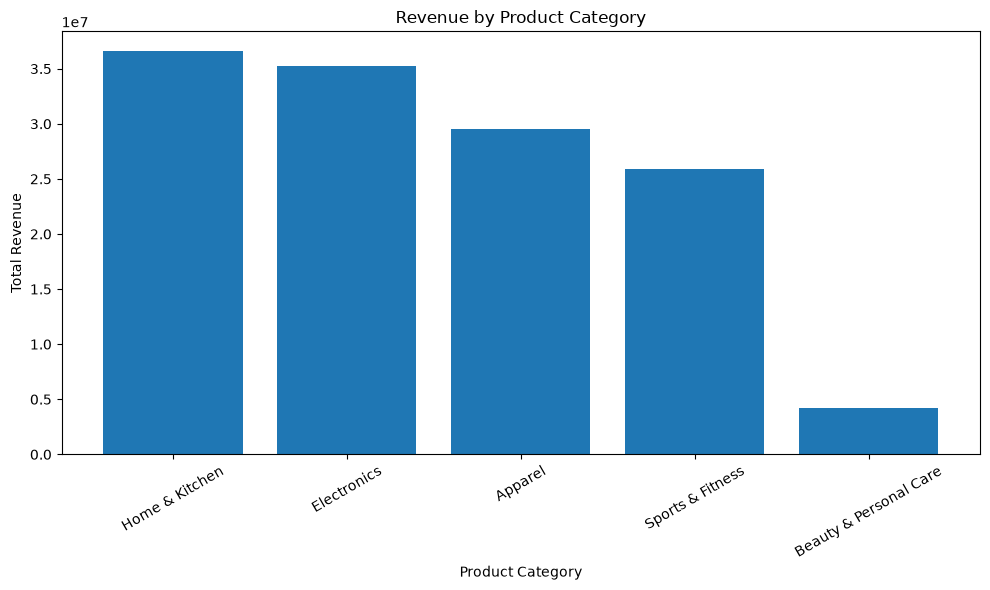

In [136]:
## Chart 4 — Which product categories generate the most revenue?
plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

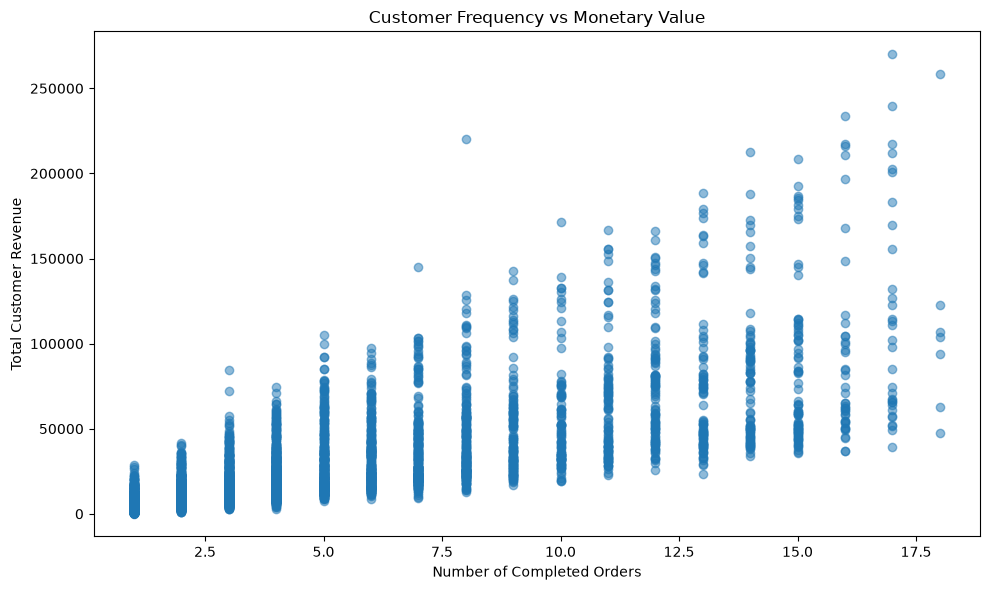

In [137]:
## Chart 5 — Does purchasing frequency relate to customer revenue?
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['frequency'],
    rfm['monetary'],
    alpha=0.5
)

plt.title('Customer Frequency vs Monetary Value')
plt.xlabel('Number of Completed Orders')
plt.ylabel('Total Customer Revenue')

plt.tight_layout()
plt.show()

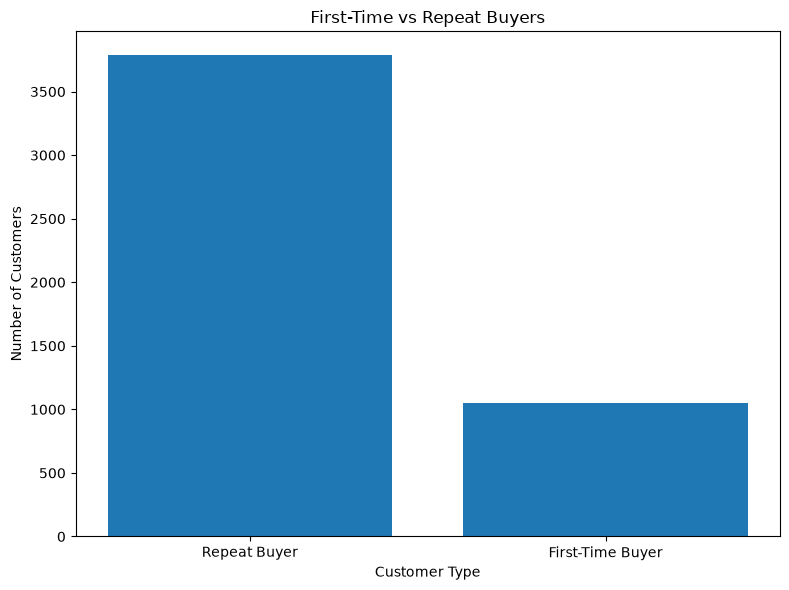

In [138]:
## Chart 6 — How many customers are first-time vs repeat buyers?
customer_orders = (
    completed_orders
    .groupby('customer_id')['order_id']
    .nunique()
)

buyer_type = customer_orders.apply(
    lambda x: 'First-Time Buyer' if x == 1 else 'Repeat Buyer'
)

buyer_counts = buyer_type.value_counts()

plt.figure(figsize=(8, 6))

plt.bar(
    buyer_counts.index,
    buyer_counts.values
)

plt.title('First-Time vs Repeat Buyers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()